In [63]:
import os
from PIL import Image, ImageDraw, ImageFont
from io import BytesIO
import requests
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [64]:
from rfdetr import RFDETRNano

model = RFDETRNano()

Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


In [65]:
url = "https://media.roboflow.com/dog.jpeg"
image = Image.open(BytesIO(requests.get(url).content))
# image = image.rotate(270, expand=True)

In [66]:
predictions = model.predict(image)
print(predictions)

Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().


Detections(xyxy=array([[  61.865128 ,  247.66312  ,  652.24835  ,  930.83813  ],
       [   1.3345814,  361.53336  ,  648.7614   , 1264.4553   ],
       [ 622.7613   ,  720.39746  ,  698.4292   ,  787.9133   ]],
      dtype=float32), mask=None, confidence=array([0.84719986, 0.7727524 , 0.5178982 ], dtype=float32), class_id=array([18,  1,  3]), tracker_id=None, data={}, metadata={})


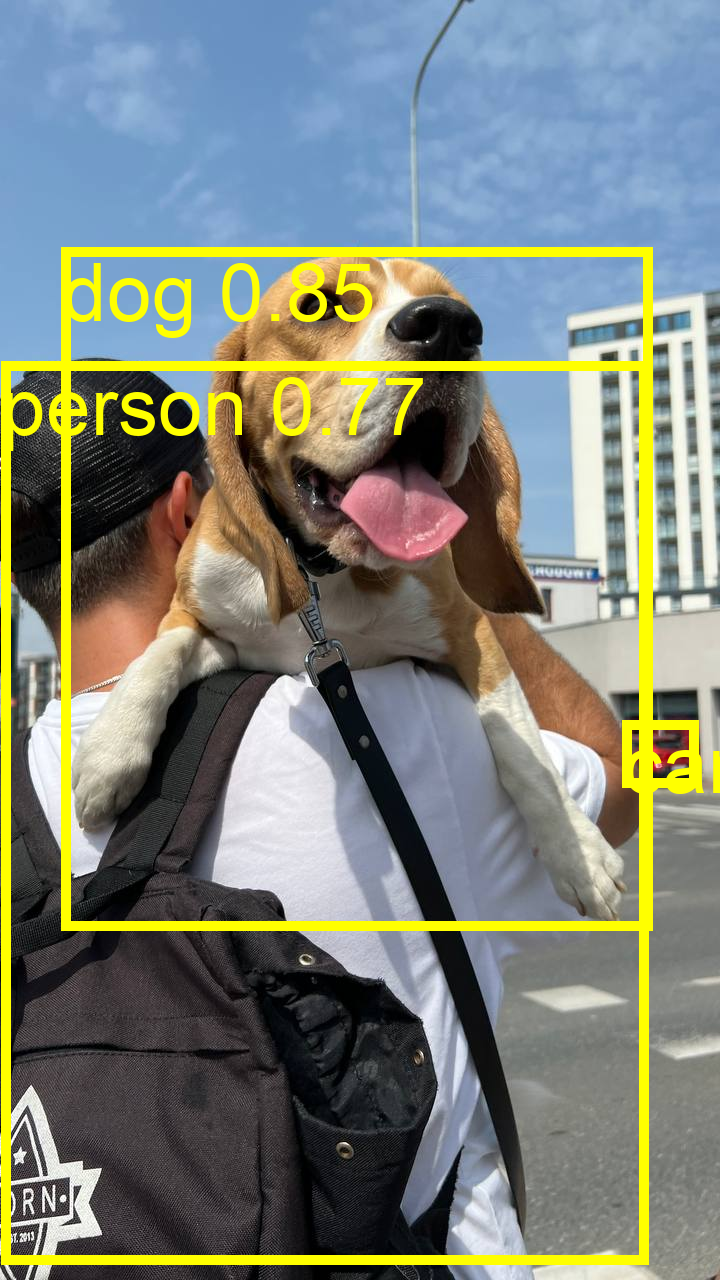

In [67]:
draw = ImageDraw.Draw(image)
font = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial.ttf", size=80)
for xyxy, conf, cls in zip(predictions.xyxy, predictions.confidence, predictions.class_id):
    draw.rectangle(xyxy, outline="yellow", width=10)
    draw.text((xyxy[0], xyxy[1]), f"{model.class_names[cls]} {conf:.2f}", fill="yellow", font=font)
image

In [68]:
model.means

[0.485, 0.456, 0.406]

In [69]:
coreml_model = model.export_coreml(output_dir="output")

Exporting model to CoreML format
PyTorch inference output shapes - Boxes: torch.Size([1, 300, 4]), Labels: torch.Size([1, 300, 91])


Tuple detected at graph output. This will be flattened in the converted model.
Running MIL backend_mlprogram pipeline: 100%|██████████| 12/12 [00:00<00:00, 156.60 passes/s]



Successfully exported CoreML model: output/inference_model.mlpackage
CoreML export completed successfully


In [70]:
import torch
import supervision as sv

In [71]:
def process_coreml_output(output, threshold, orig_size):
    predictions = {
        "pred_logits": torch.from_numpy(output["labels"]).to(model.model.device),
        "pred_boxes": torch.from_numpy(output["dets"]).to(model.model.device)
    }

    target_sizes = torch.tensor([(orig_size[1], orig_size[0])], device=model.model.device)
    results = model.model.postprocessors["bbox"](predictions, target_sizes=target_sizes)

    detections_list = []
    for result in results:
        scores = result["scores"]
        labels = result["labels"]
        boxes = result["boxes"]

        keep = scores > threshold
        scores = scores[keep]
        labels = labels[keep]
        boxes = boxes[keep]

        detections = sv.Detections(
            xyxy=boxes.float().cpu().numpy(),
            confidence=scores.float().cpu().numpy(),
            class_id=labels.cpu().numpy(),
        )
        detections_list.append(detections)

    return detections_list if len(detections_list) > 1 else detections_list[0]

In [72]:
import numpy as np

In [73]:
image = Image.open(BytesIO(requests.get(url).content))
# image = image.rotate(270, expand=True)
orig_size = image.size

In [74]:
output = coreml_model.predict({"input": image.resize((model.model.resolution, model.model.resolution))})
predictions = process_coreml_output(output, threshold=0.5, orig_size=orig_size)
predictions

Detections(xyxy=array([[  62.735905 ,  247.44942  ,  650.7225   ,  932.52716  ],
       [   1.4309907,  362.4046   ,  649.52966  , 1263.113    ],
       [ 622.45447  ,  720.3906   ,  698.7641   ,  787.94385  ]],
      dtype=float32), mask=None, confidence=array([0.8700627 , 0.7715313 , 0.51659745], dtype=float32), class_id=array([18,  1,  3]), tracker_id=None, data={}, metadata={})

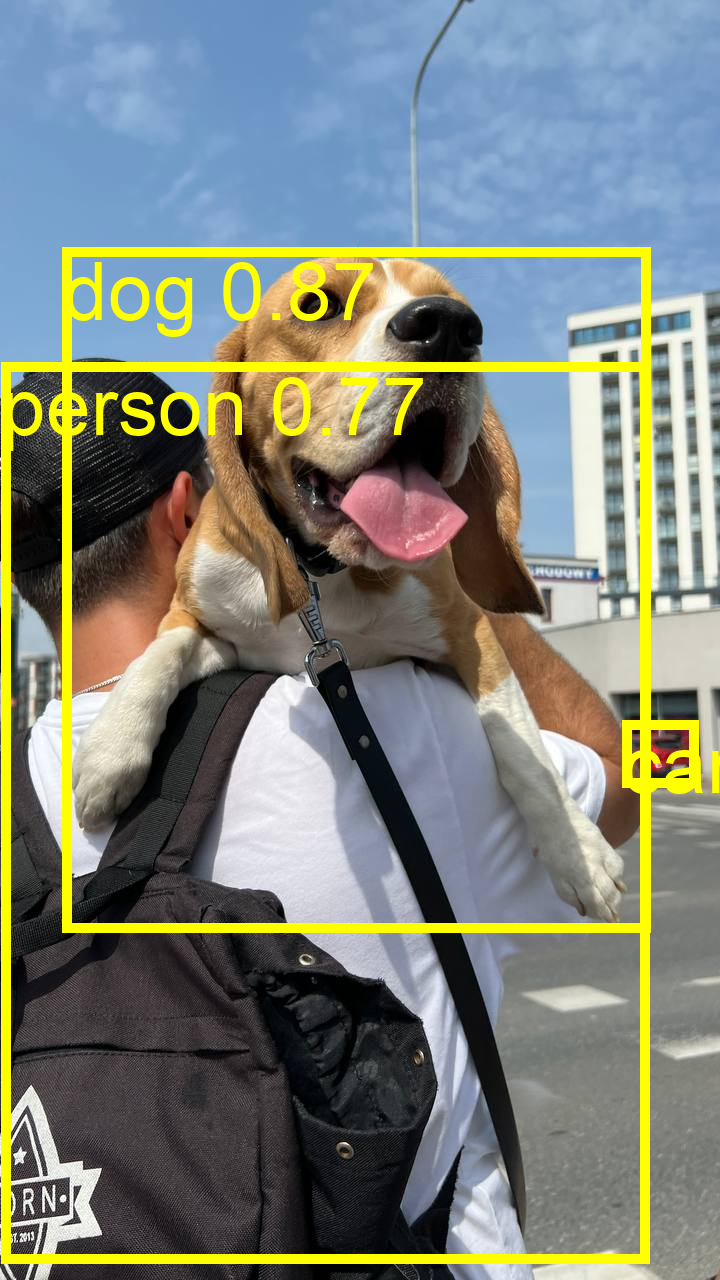

In [75]:
draw = ImageDraw.Draw(image)
font = ImageFont.truetype("/System/Library/Fonts/Supplemental/Arial.ttf", size=80)
for xyxy, conf, cls in zip(predictions.xyxy, predictions.confidence, predictions.class_id):
    draw.rectangle(xyxy, outline="yellow", width=10)
    draw.text((xyxy[0], xyxy[1]), f"{model.class_names[cls]} {conf:.2f}", fill="yellow", font=font)
image